In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

Libraries loaded successfully.


In [2]:
df = pd.read_csv("../data/credit.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1000, 21)


In [3]:
df.head()

,Creditability,Status of exsiting checking amount,Duration of Credit (month),Credit History,Purpose,Credit Amount,Savings account/bonds,Present employement since,Installment percent,Sex & Marital Status,Guarantors,Present Residence since,Property,Age (years),Other installment plans,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,1,1,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Creditability                       1000 non-null   int64
 1   Status of exsiting checking amount  1000 non-null   int64
 2   Duration of Credit (month)          1000 non-null   int64
 3   Credit History                      1000 non-null   int64
 4   Purpose                             1000 non-null   int64
 5   Credit Amount                       1000 non-null   int64
 6   Savings account/bonds               1000 non-null   int64
 7   Present employement since           1000 non-null   int64
 8   Installment percent                 1000 non-null   int64
 9   Sex & Marital Status                1000 non-null   int64
 10  Guarantors                          1000 non-null   int64
 11  Present Residence since             1000 non-null   int64
 12  Propert

In [5]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

In [6]:
df["Creditability"].value_counts(normalize=True) * 100

Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

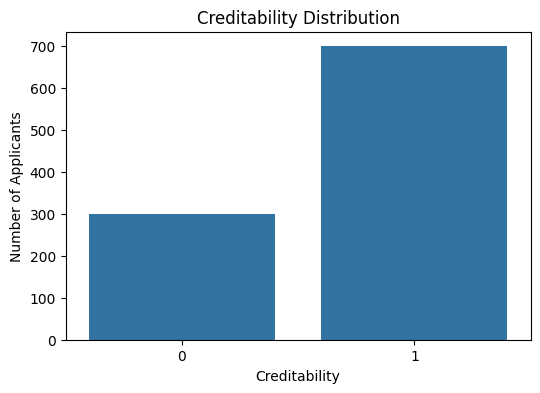

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Creditability")

plt.title("Creditability Distribution")
plt.xlabel("Creditability")
plt.ylabel("Number of Applicants")
plt.show()

In [8]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Duplicate rows:
0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Creditability,1000.0,0.700,0.458487,0.0,0.0,1.0,1.00,1.0
Status of exsiting checking amount,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
Duration of Credit (month),1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Credit History,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
Purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
Credit Amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
Savings account/bonds,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
Present employement since,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
Installment percent,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Sex & Marital Status,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
